In [41]:
# import libraries

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier 

import warnings 
warnings.filterwarnings('ignore')

### Read-in the dataset

In [42]:
# Read the "Heart.csv" dataset and take a quick look
heart = pd.read_csv('Heart.csv')

# Force the response into a binary indicator:
heart['AHD'] = 1*(heart['AHD'] == "Yes")

print(heart.shape)

(303, 15)


In [43]:
# split into train and validation
heart_train, heart_val = train_test_split(heart, train_size = 0.75, random_state = 109)

print(heart_train.shape, heart_val.shape)

(227, 15) (76, 15)


### $k$-NN model fitting

Define and fit a $k$-NN classification model with $k=20$ to predict `AHD` from `Age`.

In [44]:
# select variables for model estimation: be careful of format 
# (aka, single or double square brackets)
x_train = heart_train[['Age']]
y_train = heart_train['AHD']

# define the model
knn20 = KNeighborsClassifier(n_neighbors=20)

# fit to the data
knn20.fit( x_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",20
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


### $k$-NN prediction

Perform some simple predictions: both the pure classifications and the probability estimates.

In [45]:
### edTest(test_knn) ###

# there are two types of predictions in classification models in sklearn
# model.predict for pure classifications, and model.predict_proba for probabilities

# create the predictions based on the train data
yhat20_class = knn20.predict(x_train)
yhat20_prob = knn20.predict_proba(x_train)

# print out the first 10 predictions for the actual data
print(yhat20_class[1:10])
print(yhat20_prob[1:10])

[0 1 1 1 0 1 1 0 1]
[[0.75 0.25]
 [0.4  0.6 ]
 [0.25 0.75]
 [0.3  0.7 ]
 [0.65 0.35]
 [0.45 0.55]
 [0.35 0.65]
 [0.7  0.3 ]
 [0.35 0.65]]


### ⏸ Take a moment to consider your results so far

* What do you notice about the probability estimates?  
* Which 'column' is which in `yhat20_prob`?  
* How could you manually create `yhat20_class` from `yhat20_prob`? 


**1. What do you notice about the probability estimates?**

The probabilities in each row add up to 1. If the 20 neighbors have equal weight, each probability represents the proportion of neighbors belonging to that class.

**2. Which “column” is which in `yhat20_prob`?**

The columns follow the order in `knn20.classes_`. The first column corresponds to `knn20.classes_[0]`, and the second corresponds to `knn20.classes_[1]`.

**3. How could you manually create `yhat20_class` from `yhat20_prob`?**

I would select the column with the highest probability in each row and return its class label: `knn20.classes_[np.argmax(yhat20_prob, axis=1)]`.

## Simple logistic regression model fitting

Define and fit a simple logistic model to predict `AHD` from `Age`.

In [46]:
### edTest(test_logit) ###
# Create a logistic regression model, with None as the penalty

logit1 = LogisticRegression(penalty=None, max_iter = 1000)

#Fit the model using the training set

logit1.fit(heart_train[['Age']], heart_train['AHD'])

# Get the coefficient estimates

print("Logistic Regression Estimated Betas (B0,B1):",logit1.intercept_[0], logit1.coef_[0][0])


Logistic Regression Estimated Betas (B0,B1): -3.3261670337310845 0.059331420484571726


### Interpret the Coefficient Estimates

Recall the logistic regression formula.

$$ \ln\left(  \frac{P(Y=1)}{1-P(Y=1)} \right) = \hat{\beta}_0 + \hat{\beta}_1 X$$

Use this formula and your coefficients from above to answer the following: What is the estimated odds that a 60 year old will have AHD in the ICU?  What is the probability?

For a 60-year-old patient, the estimated log-odds of having AHD are −3.326167 + 0.0593314 × 60 = 0.233718. Therefore, the estimated odds are e^0.233718 ≈ 1.263, or about 1.26 to 1. The corresponding probability is 1.263 / (1 + 1.263) ≈ 0.558, or 55.8%.

The positive coefficient for Age means that the estimated odds of AHD increase with age. Each additional year multiplies the odds by approximately 1.061.

In [47]:
# Confirm the probability calculation you made above using logit1logit1.predict_proba()
# predict for one observation where age = 60.  Hint: double brackets is one way to do it

logit1.predict_proba([[60]])

array([[0.44183498, 0.55816502]])

### $k$-NN and logistic accuracy

In [48]:
### edTest(test_accuracy) ###

# Define the equivalent validation variables from `heart_val`

x_val = heart_val[['Age']]
y_val = heart_val['AHD']

# Compute the training & validation accuracy using the estimator.score() function

knn20_train_accuracy = knn20.score(x_train, y_train)
knn20_val_accuracy = knn20.score(x_val, y_val)

logit_train_accuracy = logit1.score(x_train, y_train)
logit_val_accuracy = logit1.score(x_val, y_val)

# Print the accuracies below

print("k-NN Train & Validation Accuracy:", knn20_train_accuracy, knn20_val_accuracy)
print("Logisitic Train & Validation Accuracy:", logit_train_accuracy, logit_val_accuracy)




k-NN Train & Validation Accuracy: 0.6563876651982379 0.5921052631578947
Logisitic Train & Validation Accuracy: 0.6387665198237885 0.6052631578947368


### Plot the predictions

Use a linspace to create a dummy x variable for plotting for the two different models.  Here we plot the train and validation data separately, and the 4 different types of predictions (2 for each model: pure classification and probability estimation)

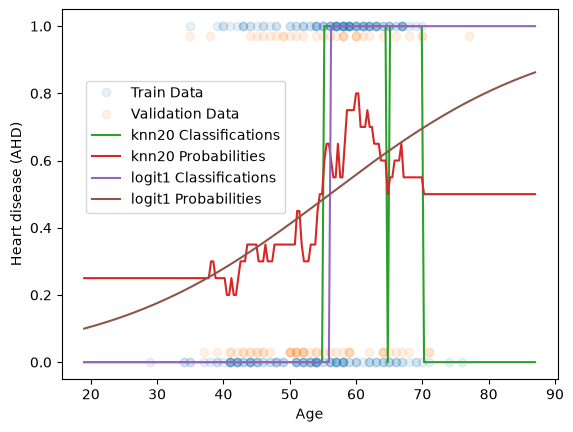

In [49]:

# set-up the dummy x for plotting: we extend it a little bit beyond the range of observed values 
x = np.linspace(np.min(heart[['Age']])-10, np.max(heart[['Age']])+10,200).reshape(-1, 1)


# be careful in pulling off only the correct column of the probability calculations: use `[:,1]`
yhat_class_knn20 = knn20.predict(x)
yhat_prob_knn20 = knn20.predict_proba(x)[:, 1]

yhat_class_logit = logit1.predict(x)
yhat_prob_logit = logit1.predict_proba(x)[:, 1]

# plot the observed data.  Note: we offset the validation points to make them more clearly differentiated from train
plt.plot(x_train, y_train, 'o' ,alpha=0.1, label='Train Data')
plt.plot(x_val, 0.94*y_val+0.03, 'o' ,alpha=0.1, label='Validation Data')

# plot the predictions
plt.plot(x, yhat_class_knn20, label='knn20 Classifications')
plt.plot(x, yhat_prob_knn20, label='knn20 Probabilities')
plt.plot(x, yhat_class_logit, label='logit1 Classifications')
plt.plot(x, yhat_prob_logit, label='logit1 Probabilities')

# put the lower-left part of the legend 5% to the right along the x-axis, and 45% up along the y-axis
plt.legend(loc=(0.05,0.45))

# Don't forget your axis labels!
plt.xlabel("Age")
plt.ylabel("Heart disease (AHD)")

plt.show()


### ⏸ Post Exercise Questions

1. Describe the estimated associations between AHD and Age based on these two models.

2. Which model apears to be more overfit to the training data?  How do you know?  How can this be resolved?

3. How could you engineer features for the logistic regression model so that the association between AHD and Age resembles the general trend in the knn20 model more similarly?

4. Refit the models above to predict `AHD` from 3 predictors ['MaxHR','Age','Sex'] (Feel free to also play around with $k$).
Investigate the associations in each of the two models and evaluate the predictive accuracy of each of these models

**1. Association between AHD and Age.** Logistic regression estimates a positive association with Age. Its Age coefficient is 0.0593, so each additional year multiplies the estimated odds of AHD by approximately 1.061 (an increase of 6.1% in the odds). Its predicted probability rises smoothly with age. The k-NN model estimates probabilities from nearby observations, so its predictions change in steps rather than following one fixed slope.

**2. Overfitting.** The k-NN model appears slightly more overfit. Its accuracy falls from 65.64% in training to 59.21% in validation, a gap of 6.43 percentage points. Logistic regression falls from 63.88% to 59.21%, a gap of 4.67 points. We could select `k` using cross-validation on the training data; a larger `k` may produce smoother predictions.

**3. Feature engineering.** We could add nonlinear Age features, such as `Age²`, or use splines in the logistic regression. This would allow its estimated association with Age to bend and resemble the overall k-NN trend more closely. We should choose the complexity using cross-validation.

**4. Using `MaxHR`, `Age`, and `Sex`, the k-NN model (k=20) achieved 74.0% training accuracy and 78.9% validation accuracy. Logistic regression achieved 70.9% and 71.1%, respectively. Both improved on the age-only models, which had 59.2% validation accuracy. On this validation split, k-NN performed better.

Holding the other predictors at typical values, both models predict a higher probability of AHD as Age increases and a lower probability as MaxHR increases. Logistic regression shows smooth trends, while k-NN shows local, stepwise changes. The logistic coefficients also indicate lower odds with higher MaxHR (−0.0383), higher odds with greater Age (+0.0395), and higher odds for `Sex=1` than for `Sex=0` (+1.2277).

With Age and MaxHR fixed at their median values, k-NN predicts AHD probabilities of 35% for `Sex=0` and 45% for `Sex=1`; logistic regression predicts 27.2% and 56.0%. These are associations in the fitted models, not evidence that the predictors cause AHD.

In [50]:
columnas = ['MaxHR', 'Age', 'Sex', 'AHD']

print(heart_train[columnas].dtypes)
display(heart_train[columnas].head())

MaxHR    int64
Age      int64
Sex      int64
AHD      int64
dtype: object


,MaxHR,Age,Sex,AHD
178,162,43,1,0
220,172,41,0,0
37,112,57,1,1
97,157,60,0,1
108,140,61,1,1


In [51]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

x_train3 = heart_train[['MaxHR', 'Age', 'Sex']]
x_val3 = heart_val[['MaxHR', 'Age', 'Sex']]
y_train3 = heart_train['AHD']
y_val3 = heart_val['AHD']

knn3 = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=20))
logit3 = LogisticRegression(penalty=None, max_iter=1000)

knn3.fit(x_train3, y_train3)
logit3.fit(x_train3, y_train3)

print("k-NN train / validation:",
      knn3.score(x_train3, y_train3),
      knn3.score(x_val3, y_val3))

print("Logistic train / validation:",
      logit3.score(x_train3, y_train3),
      logit3.score(x_val3, y_val3))

print("Logistic coefficients (MaxHR, Age, Sex):", logit3.coef_[0])

k-NN train / validation: 0.7400881057268722 0.7894736842105263
Logistic train / validation: 0.7092511013215859 0.7105263157894737
Logistic coefficients (MaxHR, Age, Sex): [-0.03825998  0.03951406  1.22774105]


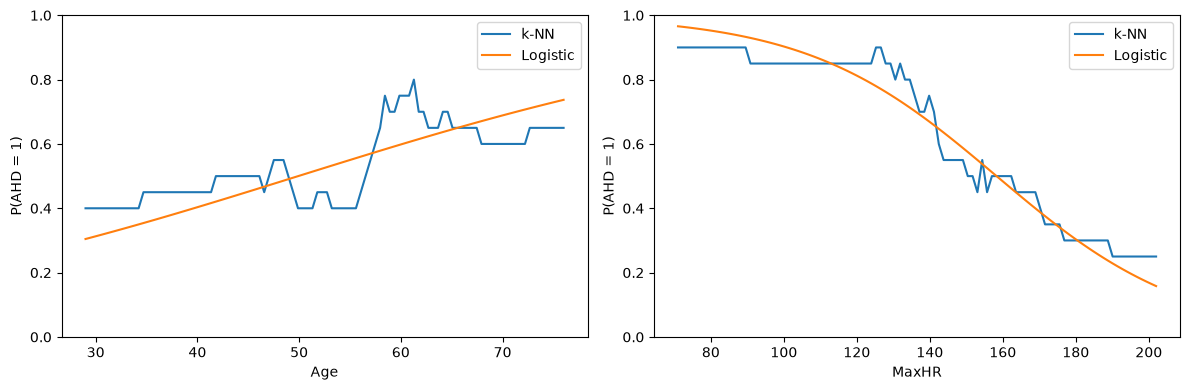

Sex=0: k-NN=0.350, Logistic=0.272
Sex=1: k-NN=0.450, Logistic=0.560


In [52]:
base = {
    'MaxHR': x_train3['MaxHR'].median(),
    'Age': x_train3['Age'].median(),
    'Sex': x_train3['Sex'].mode()[0]
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, variable in zip(axes, ['Age', 'MaxHR']):
    datos_grafico = pd.DataFrame([base] * 100)
    datos_grafico[variable] = np.linspace(
        x_train3[variable].min(),
        x_train3[variable].max(),
        100
    )

    ax.plot(datos_grafico[variable],
            knn3.predict_proba(datos_grafico)[:, 1],
            label='k-NN')
    ax.plot(datos_grafico[variable],
            logit3.predict_proba(datos_grafico)[:, 1],
            label='Logistic')

    ax.set(xlabel=variable, ylabel='P(AHD = 1)', ylim=(0, 1))
    ax.legend()

plt.tight_layout()
plt.show()

for valor_sex in [0, 1]:
    persona = pd.DataFrame([{**base, 'Sex': valor_sex}])
    print(
        f"Sex={valor_sex}:",
        f"k-NN={knn3.predict_proba(persona)[0, 1]:.3f},",
        f"Logistic={logit3.predict_proba(persona)[0, 1]:.3f}"
    )
    